In [2]:
%load_ext autoreload
%autoreload 2

import lib
import numpy as np
import matplotlib.pyplot as plt
#import pandas as pd
import os
import time




# Model parameters
S0, K = 100, 100     # Initial stock price and strike
r = 0.05             # Risk-free rate
sigma = 0.3          # Volatility
gamma = 1.2          # CEV parameter
T = 1.0              # Time to maturity
M = 252              # Number of time steps (daily)

# Create simulation instance
sim = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M)

# Set simulation parameters
N = 2**17            # Number of paths (power of 2 for QMC)
batches = 32          # Number of batches/scrambles

## Euler vs Milstein comparison
This notebook compares the Euler (weak Euler) and Milstein-like scheme implemented in `lib.MonteCarloSimulation`.
We compute (1) pathwise differences at the current `M`, and (2) an estimate of the strong error by comparing coarse time-grids to a fine Milstein reference using the same Brownian paths.

In [3]:
# Basic, quick comparison at the current M stored in `sim`
# Generate common normals and compare terminal prices under Euler vs Milstein (pathwise)
N_quick = 2**19  # modest number of paths for quick check
seed = sim.base_seed
Z_q = sim.draw_pseudo_random_numbers(seed, N_quick, sim.M)
# Euler scheme (euler=True) and Milstein-like (euler=False)
S_euler = sim.sim_CEV_paths(N_quick, Z_q, euler=True)
S_mil = sim.sim_CEV_paths(N_quick, Z_q, euler=False)
# Terminal prices
Se_T = S_euler[:, -1]
Sm_T = S_mil[:, -1]
# Pathwise differences and summary metrics
abs_diff = np.abs(Se_T - Sm_T)
l1 = abs_diff.mean()
l2 = np.sqrt((abs_diff**2).mean())
l_inf = abs_diff.max()
print(f'N={N_quick}, M={sim.M} (dt={sim.dt:.5g})')
print(f'Mean |Se-Sm| = {l1:.6e}, L2 = {l2:.6e}, Linf = {l_inf:.6e}')

N=524288, M=252 (dt=0.0039683)
Mean |Se-Sm| = 4.740161e-01, L2 = 1.365970e+00, Linf = 3.092693e+02


In [4]:
# Strong convergence experiment: compare coarse schemes to a fine Milstein reference.
# We generate fine increments Z_fine and aggregate to coarser time-grids so Brownian paths are consistent.
N = 2**16             # number of paths (adjustable)
M_ref = 2048*2*2         # fine reference mesh (must be multiple of coarse meshes)
sim_ref = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M_ref)
# draw fine standard normals (shape N x M_ref)
Z_fine = sim_ref.draw_pseudo_random_numbers(sim_ref.base_seed, N, M_ref)
dt_ref = T / M_ref
dW_fine = np.sqrt(dt_ref) * Z_fine
# list of coarse meshes to test (must divide M_ref)
M_list = [8, 16, 32, 64, 128, 256, 512, 1024]
M_list = [m for m in M_list if M_ref % m == 0]
errors_euler = []
errors_mil = []
dts = []
S_eT_list = []
S_mT_list = []
# compute fine reference terminal prices using Milstein-like scheme
Sref = sim_ref.sim_CEV_paths(N, Z_fine, euler=False)
Sref_T = Sref[:, -1]
for M_coarse in M_list:
    block = M_ref // M_coarse
    # aggregate dW_fine in blocks -> dW_coarse shape (N, M_coarse)
    dW_coarse = dW_fine.reshape(N, M_coarse, block).sum(axis=2)
    dt_coarse = T / M_coarse
    Z_coarse = dW_coarse / np.sqrt(dt_coarse)
    # create sim instance for coarse grid (so self.M matches Z length)
    sim_coarse = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M_coarse)
    # Euler on coarse grid
    S_e = sim_coarse.sim_CEV_paths(N, Z_coarse, euler=True)
    # Milstein-like on coarse grid
    S_m = sim_coarse.sim_CEV_paths(N, Z_coarse, euler=False)
    # terminal values
    SeT = S_e[:, -1]
    SmT = S_m[:, -1]
    # store terminal arrays for later MC-noise analysis
    S_eT_list.append(SeT)
    S_mT_list.append(SmT)
    # compute L2 (root mean square) strong error against fine Milstein reference
    err_e = np.sqrt(((SeT - Sref_T)**2).mean())
    err_m = np.sqrt(((SmT - Sref_T)**2).mean())
    errors_euler.append(err_e)
    errors_mil.append(err_m)
    dts.append(dt_coarse)
    print(f'M={M_coarse:5d}, dt={dt_coarse:.3e}, Euler L2={err_e:.3e}, Milstein L2={err_m:.3e}')
# convert to arrays for plotting/fitting
dts = np.array(dts)
errors_euler = np.array(errors_euler)
errors_mil = np.array(errors_mil)
# keep terminal arrays as a numpy array of shape (len(M_list), N) for analysis
S_eT_array = np.vstack([arr for arr in S_eT_list])  # shape (K, N)
S_mT_array = np.vstack([arr for arr in S_mT_list])  # shape (K, N)
# Fit slopes in log-log (ignore leading coarse points if noisy)
fit_idx = slice(None)
slope_e, intercept_e = np.polyfit(np.log(dts[fit_idx]), np.log(errors_euler[fit_idx]), 1)
slope_m, intercept_m = np.polyfit(np.log(dts[fit_idx]), np.log(errors_mil[fit_idx]), 1)
print()
print(f'Fitted slopes (log-error vs log-dt): Euler {slope_e:.3f}, Milstein {slope_m:.3f}')

M=    8, dt=1.250e-01, Euler L2=1.034e+01, Milstein L2=6.364e+00
M=   16, dt=6.250e-02, Euler L2=6.760e+00, Milstein L2=3.240e+00
M=   32, dt=3.125e-02, Euler L2=3.990e+00, Milstein L2=1.777e+00
M=   64, dt=1.562e-02, Euler L2=2.400e+00, Milstein L2=8.593e-01
M=  128, dt=7.812e-03, Euler L2=1.815e+00, Milstein L2=4.310e-01
M=  256, dt=3.906e-03, Euler L2=1.263e+00, Milstein L2=1.989e-01
M=  512, dt=1.953e-03, Euler L2=8.104e-01, Milstein L2=9.903e-02
M= 1024, dt=9.766e-04, Euler L2=6.578e-01, Milstein L2=4.623e-02

Fitted slopes (log-error vs log-dt): Euler 0.577, Milstein 1.016


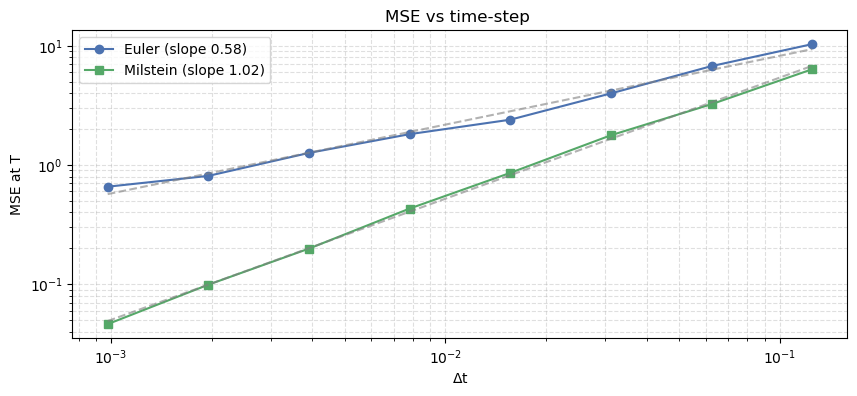

In [8]:
# Plot results (log-log)
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.loglog(dts, errors_euler, '-o', label=f'Euler (slope {slope_e:.2f})',color='#4C72B0')
plt.loglog(dts, errors_mil, '-s', label=f'Milstein (slope {slope_m:.2f})',color='#55A868')
# reference lines showing expected slopes: 0.5 and 1.0 (scaled)
# choose scale so they appear near the data
ref_x = np.array([dts.min(), dts.max()])
ref_e = np.exp(intercept_e) * ref_x**slope_e
ref_m = np.exp(intercept_m) * ref_x**slope_m
plt.loglog(ref_x, ref_e, '--', color='gray', alpha=0.6)
plt.loglog(ref_x, ref_m, '--', color='gray', alpha=0.6)
plt.xlabel('$\Delta$t')
plt.ylabel('MSE at T')
plt.title('MSE vs time-step ')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.savefig(os.path.join('Graphs', 'EUMIL.png'), dpi=300)
plt.show()

M    h        L2_Euler    SE(L2)_E    SE/L2   L2_Milstein  SE(L2)_M   SE/L2
   8 1.2e-01  8.172e+00  8.341e-01  0.102    5.185e+00  6.003e-01  0.116
  16 6.2e-02  5.523e+00  7.261e-01  0.131    2.642e+00  3.055e-01  0.116
  32 3.1e-02  3.466e+00  2.882e-01  0.083    1.360e+00  1.633e-01  0.120
  64 1.6e-02  2.452e+00  1.668e-01  0.068    6.819e-01  7.956e-02  0.117
 128 7.8e-03  1.800e+00  1.181e-01  0.066    3.317e-01  3.950e-02  0.119
 256 3.9e-03  1.077e+00  3.725e-02  0.035    1.644e-01  1.982e-02  0.121
 512 2.0e-03  8.008e-01  3.806e-02  0.048    7.699e-02  9.638e-03  0.125
1024 9.8e-04  6.382e-01  6.781e-02  0.106    3.266e-02  3.899e-03  0.119

Max relative SE: Euler 0.131, Milstein 0.125


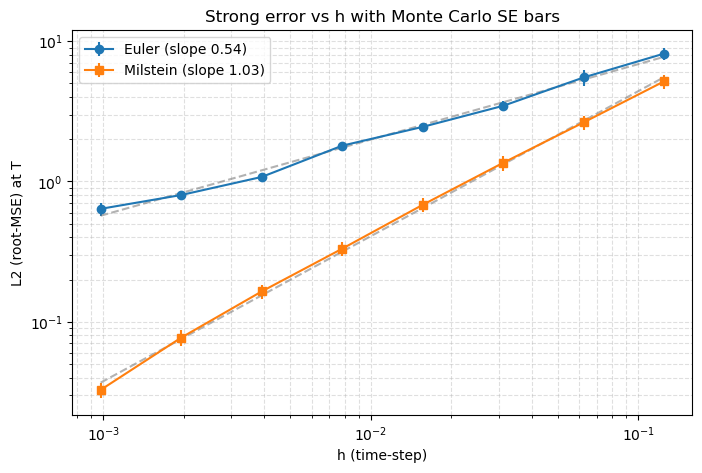

In [ ]:
# Verify Monte Carlo sampling noise for the L2 estimates and add error bars to the plot
# We compute per-path squared errors, estimate the sampling SE of the MSE,
# and propagate to the SE of the L2 estimate using the delta method.
K = len(M_list)
N_paths = S_eT_array.shape[1]
se_euler = []
se_mil = []
mse_e = []
mse_m = []
for k in range(K):
    sq_e = (S_eT_array[k, :] - Sref_T)**2
    sq_m = (S_mT_array[k, :] - Sref_T)**2
    # sample MSE and its SE (std of sample / sqrt(N))
    mse_e_k = sq_e.mean()
    mse_m_k = sq_m.mean()
    var_e = sq_e.var(ddof=1)
    var_m = sq_m.var(ddof=1)
    se_mse_e = (var_e / N_paths)**0.5
    se_mse_m = (var_m / N_paths)**0.5
    L2_e = mse_e_k**0.5
    L2_m = mse_m_k**0.5
    # delta-method approximation for SE of sqrt(MSE): se(L2) ~= se(MSE)/(2*L2)
    se_L2_e = se_mse_e / (2*L2_e) if L2_e > 0 else float('nan')
    se_L2_m = se_mse_m / (2*L2_m) if L2_m > 0 else float('nan')
    se_euler.append(se_L2_e)
    se_mil.append(se_L2_m)
    mse_e.append(mse_e_k)
    mse_m.append(mse_m_k)
se_euler = np.array(se_euler)
se_mil = np.array(se_mil)
mse_e = np.array(mse_e)
mse_m = np.array(mse_m)
# Print a summary table showing L2 and its SE and the relative SE fraction
print('M    h        L2_Euler    SE(L2)_E    SE/L2   L2_Milstein  SE(L2)_M   SE/L2')
for i, Mco in enumerate(M_list):
    h = dts[i]
    L2e = errors_euler[i]
    s_e = se_euler[i]
    r_e = s_e / L2e if L2e>0 else float('nan')
    L2m = errors_mil[i]
    s_m = se_mil[i]
    r_m = s_m / L2m if L2m>0 else float('nan')
    print(f'{Mco:4d} {h:.1e} {L2e:10.3e} {s_e:10.3e} {r_e:6.3f} {L2m:12.3e} {s_m:10.3e} {r_m:6.3f}')
# Check whether MC noise is negligible: use threshold (relative SE < 5%)
thresh = 0.05
max_rel_e = np.nanmax(se_euler / errors_euler)
max_rel_m = np.nanmax(se_mil / errors_mil)
print()
print(f'Max relative SE: Euler {max_rel_e:.3f}, Milstein {max_rel_m:.3f}')
if max_rel_e < thresh and max_rel_m < thresh:
    print('Monte Carlo sampling noise is negligible (relative SE < 5%) for both schemes in the displayed h-range.')
else:
    print('Warning: Monte Carlo noise is not negligible for some h; consider increasing N or reporting error bars.')
# Replot with error bars
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.errorbar(dts, errors_euler, yerr=se_euler, fmt='-o', label=f'Euler (slope {slope_e:.2f})')
plt.errorbar(dts, errors_mil, yerr=se_mil, fmt='-s', label=f'Milstein (slope {slope_m:.2f})')
ref_x = np.array([dts.min(), dts.max()])
ref_e = np.exp(intercept_e) * ref_x**slope_e
ref_m = np.exp(intercept_m) * ref_x**slope_m
plt.loglog(ref_x, ref_e, '--', color='gray', alpha=0.6)
plt.loglog(ref_x, ref_m, '--', color='gray', alpha=0.6)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('h (time-step)')
plt.ylabel('L2 (root-MSE) at T')
plt.title('Strong error vs h with Monte Carlo SE bars')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.show()

\noindent\textbf{Implementation details and verification.}\\
Clipping and mild stabilisation are enabled in the simulation implementation: the constructor of `lib.MonteCarloSimulation` uses default parameters `safe_clip=True`, `S_max=1e7`, `log_exp_clip=15.0` and `pow_term_max=1e8` to avoid numerical overflow when computing power terms for the CEV model (these thresholds are applied to log-values and pow-terms inside `sim_CEV_paths`).\\
The figure was produced using a Milstein-like fine reference with `M_ref=8192` time-steps and `N=2^{16}` Monte Carlo paths; common random numbers were used by aggregating fine increments to coarser grids so that each coarse solver sees the same Brownian increments. The verification cell above computes the sampling standard error (SE) of the estimated MSE and propagates it to an SE for the reported L2 (root-MSE) values using the delta method; it prints a small table and a maximum relative-SE summary and overlays SE error bars on the log–log plot. If the maximum relative SE is below 5 for both schemes the notebook prints that Monte Carlo noise is negligible; otherwise increase `N` or report the error bars in the paper.\\
Use the printed table and the overlaid error bars to support the claim in the paper that Monte Carlo sampling noise is negligible for the reported data, and cite the clipping thresholds above when stating implementation details.

In [ ]:
# Paste into the notebook after the verification cell (it uses variables already computed there)
# Choose target relative SE:
r_target = 0.05   # set to 0.02 for stricter target

# Current settings (these variables are created earlier in the notebook)
N0 = int(N)  # current N used in the experiment
max_rel_e = float(np.nanmax(se_euler / errors_euler))
max_rel_m = float(np.nanmax(se_mil / errors_mil))
max_rel = max(max_rel_e, max_rel_m)

print(f'Current N = {N0:,}')
print(f'Worst-case relative SE: Euler {max_rel_e:.4f}, Milstein {max_rel_m:.4f} -> using max {max_rel:.4f}')

if max_rel <= r_target:
    print(f'No increase needed: max_rel ({max_rel:.4f}) <= r_target ({r_target:.4f}).')
else:
    N_needed = int(np.ceil(N0 * (max_rel / r_target)**2))
    # If you want a power-of-two for QMC, round up to next power of 2:
    def next_power_of_two(x):
        return 1 << (int(np.ceil(np.log2(x))))
    N_needed_pow2 = next_power_of_two(N_needed)
    print(f'Required N (naive) to reach relative SE {r_target:.3f}: {N_needed:,}')
    print(f'Recommend rounding to power-of-two for QMC: {N_needed_pow2:,}')
    print('Or consider variance reduction (control variates / antithetic / RQMC) which can be cheaper.\n')

# Optional: automatically update N and re-run the heavy experiment
# WARNING: this can be expensive. Uncomment to run (and adjust N_new).
# N = N_needed_pow2
# print(f'Running experiment again with N={N}')
# (Re-run the strong-convergence cell code block now that N is updated)

Current N = 65,536
Worst-case relative SE: Euler 0.1315, Milstein 0.1252 -> using max 0.1315
Required N (naive) to reach relative SE 0.050: 453,054
Recommend rounding to power-of-two for QMC: 524,288
Or consider variance reduction (control variates / antithetic / RQMC) which can be cheaper.

